In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [6]:
df = pd.read_csv("../data/raw/Superstore_sales.csv",encoding='latin1')

In [7]:
x = df[['Quantity','Discount','Profit']]

y = df['Sales']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
predictions = model.predict(x_test)
print(predictions[:5])

[231.03643297 132.81453205  91.79859256 157.77052238 146.43691693]


In [11]:
mae = mean_absolute_error(y_test,predictions)
print("Mean absolute error:",mae)

Mean absolute error: 245.07556984450275


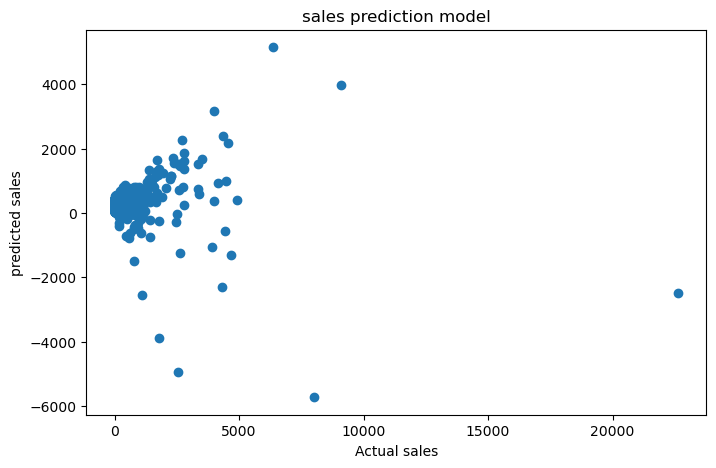

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,predictions)

plt.xlabel("Actual sales")
plt.ylabel("predicted sales")
plt.title("sales prediction model")

plt.show()


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [14]:
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42)

rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
rf_predictions = rf_model.predict(x_test)

In [16]:
rf_mae = mean_absolute_error(y_test,rf_predictions)

print("Random Forest Mae:",rf_mae)

Random Forest Mae: 101.78811500519515


In [18]:
r2 = r2_score(y_test,rf_predictions)

print("R2 score:",r2)

R2 score: 0.5545693379218537


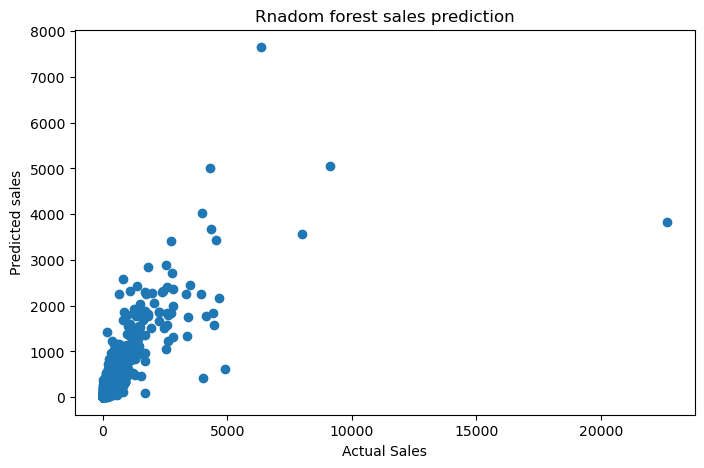

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,rf_predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted sales")
plt.title("Rnadom forest sales prediction")
plt.show()

In [22]:
feature_importance = pd.DataFrame({"feature": x.columns,"Importance": rf_model.feature_importances_ })
feature_importance = feature_importance.sort_values(by="Importance",
                                                    ascending=False)

print(feature_importance)

    feature  Importance
2    Profit    0.918805
1  Discount    0.046141
0  Quantity    0.035054


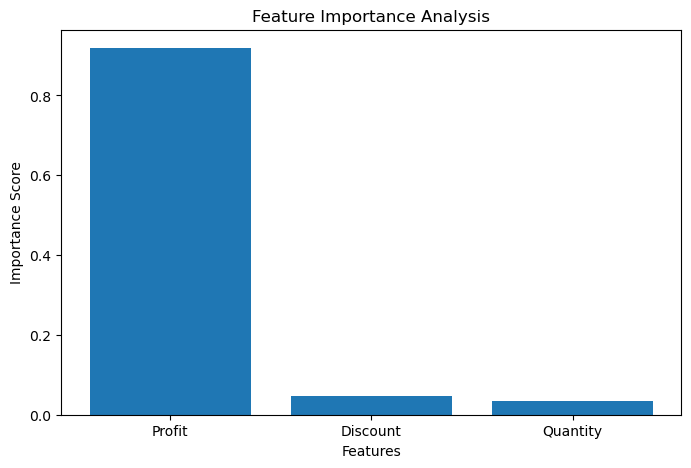

In [25]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance['feature'],feature_importance['Importance'])

plt.title("Feature Importance Analysis")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [26]:
X = df[['Quantity', 'Discount']]
y = df['Sales']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 257.81820934146276
